# Finite-size scaling — $h_c(L)$ and extrapolation
Fit BFFM $\\rho_Z$ and Rényi $S_2$ vs $h_z$ per $L$ with a symmetric tanh and an asymmetric Richards curve; $h_c$ = inflection. Then extrapolate $h_c(L)=h_c+b\\,L^{-x}$.

In [130]:
import json, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
NQS = Path("../results/nqs")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)

In [ ]:
def sweep(L):                                   # {hz: data} for finite (non-diverged) runs
    out = {}
    for p in sorted(NQS.glob(f"G-equiv_1_L{L}_hx0.00_hz*.json")):
        m = re.search(r"hz([\d.]+)\.json", p.name)
        if not m:                               # skip variant files (e.g. *_tf.json)
            continue
        hz = float(m.group(1))
        E = np.array([complex(x).real for x in json.load(open(p))["energy"]])
        if np.isfinite(E[-1]):
            out[hz] = json.load(open(p))
    return out

Ls   = [6, 8, 10, 12]
data = {L: sweep(L) for L in Ls}
cols = dict(zip(Ls, plt.cm.plasma(np.linspace(0, 0.85, len(Ls)))))

bffm_z = lambda d: d["order_params"]["WilsonBFFM"][-1][6] if d["order_params"]["WilsonBFFM"] else np.nan
renyi2 = lambda d: d["order_params"]["renyi2_entropy"][-1][0] if d["order_params"]["renyi2_entropy"] else np.nan
OBS = {"BFFM $\\rho_Z$": bffm_z, "Rényi $S_2$": renyi2}

def curve(L, fn):
    hz = np.array(sorted(data[L]))
    return hz, np.array([fn(data[L][h]) for h in hz])

tanh_f = lambda h, A, B, hc, w: A + B * np.tanh((h - hc) / w)
rich_f = lambda h, A, K, h0, w, nu: A + (K - A) / (1 + np.exp(-(h - h0) / w))**nu

def fit(x, y, form):
    """return (h_c, h_c_err, popt); errors from fit covariance (underestimated)."""
    if form == "tanh":
        p0 = [y.mean(), (y[-1] - y[0]) / 2, x[len(x)//2], 0.05]
        b  = ([-np.inf, -np.inf, x.min(), 1e-4], [np.inf, np.inf, x.max(), 1.0])
        popt, pcov = curve_fit(tanh_f, x, y, p0=p0, bounds=b, maxfev=40000)
        return popt[2], np.sqrt(pcov[2, 2]), popt
    p0 = [y[0], y[-1], x[len(x)//2], 0.03, 1.0]
    b  = ([-np.inf, -np.inf, x.min(), 1e-4, 1e-2], [np.inf, np.inf, x.max(), 1.0, 50])
    popt, pcov = curve_fit(rich_f, x, y, p0=p0, bounds=b, maxfev=60000)
    A, K, h0, w, nu = popt
    hc = h0 + w * np.log(nu)                      # inflection (NOT h0 when nu != 1)
    g  = np.array([0, 0, 1, np.log(nu), w / nu])
    return hc, float(np.sqrt(g @ pcov @ g)), popt

In [132]:
# --- knob: hz window used by the fits ---
HZ_FIT = (0.25, 0.50)      # (lo, hi); Richards needs ~>=8 points to be stable

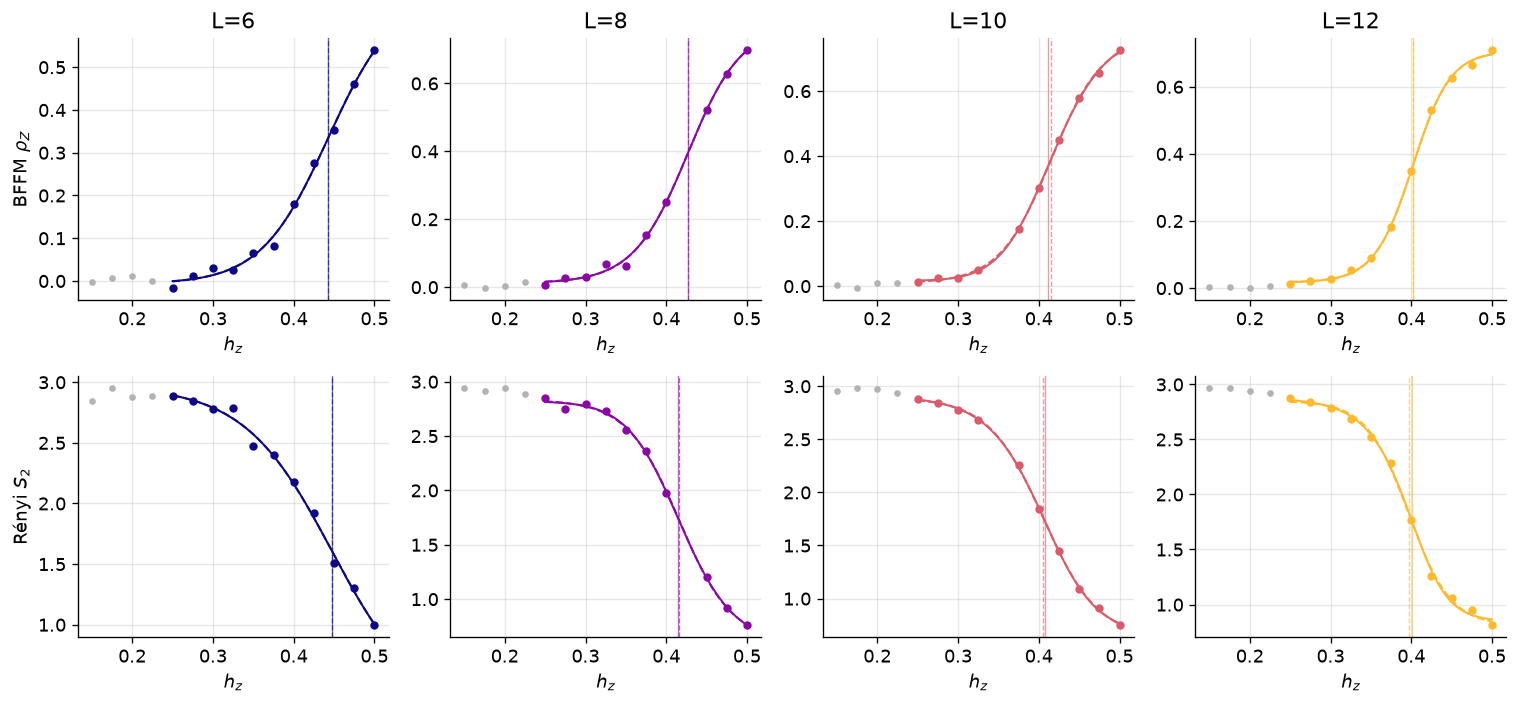

In [133]:
HC = {}                                          # (obs, form) -> {L: (h_c, err)}
fig, axes = plt.subplots(len(OBS), len(Ls), figsize=(3.2*len(Ls), 3.0*len(OBS)), squeeze=False)
for r, (oname, fn) in enumerate(OBS.items()):
    for c, L in enumerate(Ls):
        ax = axes[r][c]; hz, y = curve(L, fn)
        m = (hz >= HZ_FIT[0]) & (hz <= HZ_FIT[1]); x, yy = hz[m], y[m]
        ax.plot(hz, y, "o", color="0.7", ms=3)
        ax.plot(x, yy, "o", color=cols[L], ms=4)
        xs = np.linspace(x.min(), x.max(), 200)
        for form, ff, ls in [("tanh", tanh_f, "--"), ("rich", rich_f, "-")]:
            try:
                hc, err, popt = fit(x, yy, form)
                ax.plot(xs, ff(xs, *popt), ls, color=cols[L], lw=1.2)
                ax.axvline(hc, color=cols[L], ls=ls, lw=0.8, alpha=0.6)
                HC.setdefault((oname, form), {})[L] = (hc, err)
            except Exception as e:
                print(f"{oname} L={L} {form}: fit failed ({e})")
        if r == 0: ax.set_title(f"L={L}")
        if c == 0: ax.set_ylabel(oname)
        ax.set_xlabel("$h_z$")
fig.tight_layout()
# fig.savefig(FIG / "fss_fits.png", dpi=300, bbox_inches="tight")

In [134]:
print(f"h_c(L) over hz in {HZ_FIT}  (— errors from fit covariance, underestimated)\n")
for (oname, form), d in HC.items():
    row = "  ".join(f"L{L}={d[L][0]:.4f}±{d[L][1]:.4f}" for L in Ls if L in d)
    print(f"{oname:14s} [{form:4s}]  {row}")

h_c(L) over hz in (0.25, 0.5)  (— errors from fit covariance, underestimated)

BFFM $\rho_Z$  [tanh]  L6=0.4428±0.0090  L8=0.4265±0.0041  L10=0.4152±0.0013  L12=0.4016±0.0012
BFFM $\rho_Z$  [rich]  L6=0.4425±0.0103  L8=0.4272±0.0077  L10=0.4116±0.0029  L12=0.4025±0.0034
Rényi $S_2$    [tanh]  L6=0.4477±0.0187  L8=0.4163±0.0028  L10=0.4055±0.0014  L12=0.3966±0.0021
Rényi $S_2$    [rich]  L6=0.4471±0.0192  L8=0.4142±0.0056  L10=0.4080±0.0034  L12=0.4015±0.0055


h_c(inf) = h_c + b·L^(-x)   [x fixed=1.590]

  tanh  BFFM $\rho_Z$   0.3756 ± 0.0038
  tanh  Rényi $S_2$     0.3753 ± 0.0051
  rich  BFFM $\rho_Z$   0.3821 ± 0.0068
  rich  Rényi $S_2$     0.3844 ± 0.0101


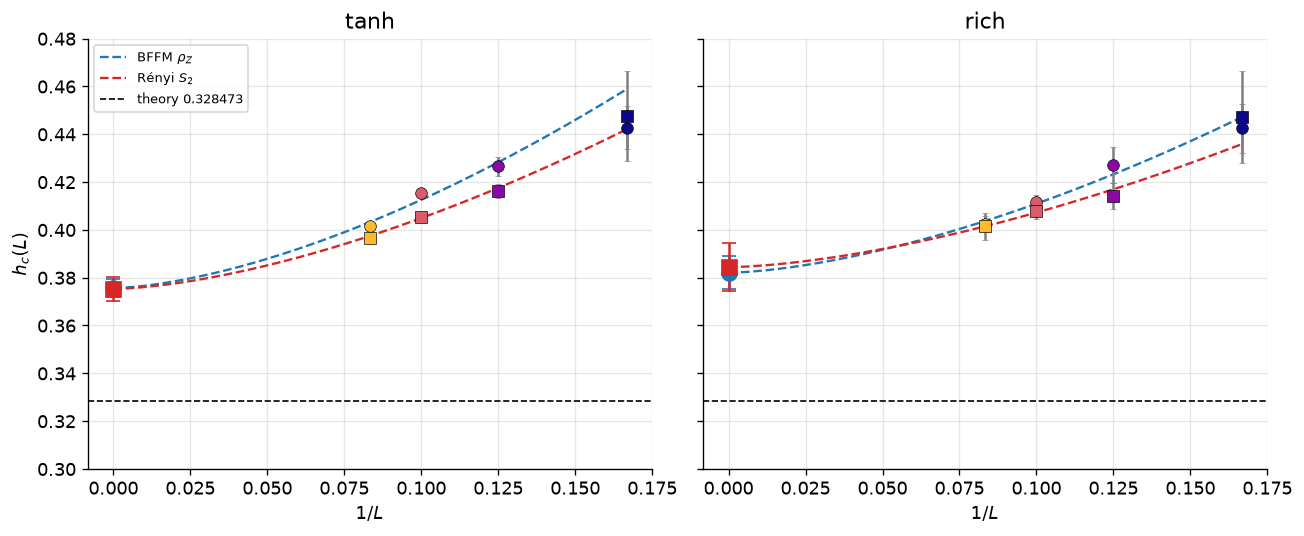

In [135]:
# --- knobs ---
FIX_X    = 1/0.629         # exponent: fix (1/nu_3DIsing ~ 1.59) or None to fit it (degenerate with 4 L)
H_THEORY = 0.328473        # expected 3D-Ising* critical field, h_c = 0.328473(2)

def fss(Ls_, hc, err, fix_x):
    iL = 1.0 / np.array(Ls_, float)
    s  = np.array(err) if np.all(np.isfinite(err)) and np.all(np.array(err) > 0) else None
    if fix_x is None:
        f = lambda t, hcinf, b, x: hcinf + b * t**x; p0 = [min(hc), max(hc) - min(hc), 1.5]
    else:
        f = lambda t, hcinf, b: hcinf + b * t**fix_x; p0 = [min(hc), max(hc) - min(hc)]
    popt, pcov = curve_fit(f, iL, hc, p0=p0, sigma=s, absolute_sigma=s is not None, maxfev=40000)
    return popt, np.sqrt(np.diag(pcov)), f

ocol = {"BFFM $\\rho_Z$": "tab:blue", "Rényi $S_2$": "tab:red"}   # observable -> colour
omrk = {"BFFM $\\rho_Z$": "o",        "Rényi $S_2$": "s"}         # observable -> marker

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
tt = np.linspace(0, 1/min(Ls), 200)
print(f"h_c(inf) = h_c + b·L^(-x)   [x {'fixed='+format(FIX_X,'.3f') if FIX_X else 'fitted'}]\n")
for ax, form in zip(axes, ["tanh", "rich"]):
    for oname, fn in OBS.items():
        d = HC[(oname, form)]; Lk = [L for L in Ls if L in d]
        hc = [d[L][0] for L in Lk]; er = [d[L][1] for L in Lk]
        popt, perr, f = fss(Lk, hc, er, FIX_X)
        for L in Lk:                                                    # points: fill = L colour
            ax.errorbar(1/L, d[L][0], yerr=d[L][1], fmt=omrk[oname], mfc=cols[L], mec="k",
                        mew=0.4, ms=7, ecolor="0.5", capsize=2, zorder=3)
        ax.plot(tt, f(tt, *popt), "--", color=ocol[oname], lw=1.4, label=oname)   # dashed extrap
        ax.errorbar(0, popt[0], yerr=perr[0], fmt=omrk[oname], mfc=ocol[oname], mec=ocol[oname],
                    ms=9, ecolor=ocol[oname], capsize=4, zorder=4)      # extrapolated value + error
        print(f"  {form:4s}  {oname:14s}  {popt[0]:.4f} ± {perr[0]:.4f}")
    ax.axhline(H_THEORY, color="k", ls="--", lw=1, label=f"theory {H_THEORY}")
    ax.set(xlabel="$1/L$", title=form, ylim=(0.30, 0.48))
axes[0].set_ylabel("$h_c(L)$")
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
# fig.savefig(FIG / "fss_extrapolation.png", dpi=300, bbox_inches="tight")

x=1.0:  h_c(inf) = 0.3453 ± 0.0171   b = 0.598
x=1.5:  h_c(inf) = 0.3685 ± 0.0116   b = 1.140
x=2.0:  h_c(inf) = 0.3801 ± 0.0091   b = 2.409


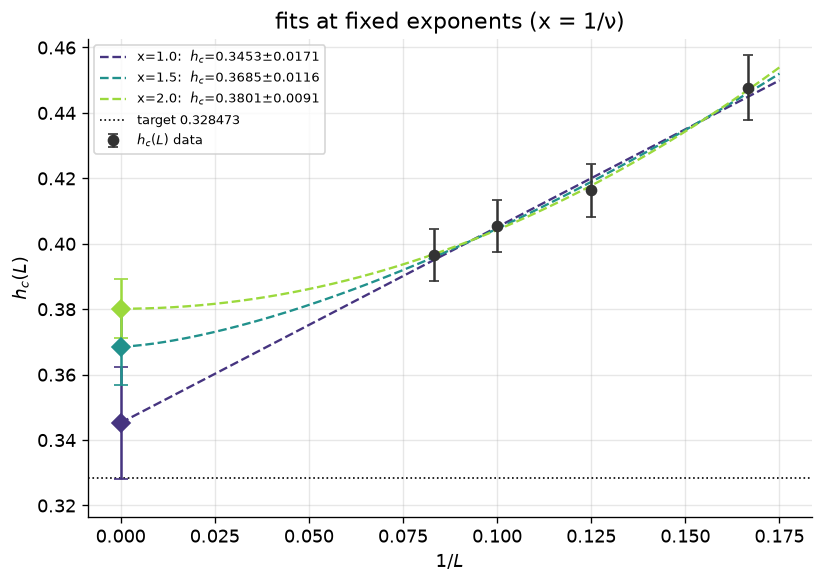

In [150]:
# --- h_c(L) vs 1/L with best fits at several FIXED exponents x ---
# free x is degenerate (4 pts); so fix x, fit h_c+b (stable), for a few x values
# and compare their extrapolations (error-barred) at 1/L -> 0.

HC_MANUAL = {6: (0.4477, 0.010), 8: (0.4163, 0.008), 10: (0.4055, 0.008), 12: (0.3966, 0.008)}
H_TARGET  = 0.328473       # known h_c(inf)
X_LIST    = [1.0, 1.5, 2.0]   # fixed exponents to overlay

Lk = sorted(HC_MANUAL); iL = 1/np.array(Lk, float)
y  = np.array([HC_MANUAL[L][0] for L in Lk]); e = np.array([HC_MANUAL[L][1] for L in Lk])
model = lambda x: (lambda t, hc, b: hc + b*t**x)     # x baked in; fit h_c and b only

fig, ax = plt.subplots(figsize=(7, 5))
tt = np.linspace(0, iL.max()*1.05, 200)
ax.errorbar(iL, y, yerr=e, fmt="o", color="0.2", ms=6, capsize=3, zorder=5, label="$h_c(L)$ data")
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(X_LIST)))
hc_all = []
for x, c in zip(X_LIST, cmap):
    popt, pcov = curve_fit(model(x), iL, y, p0=[y.min(), 0.5], sigma=e,
                           absolute_sigma=True, maxfev=100000)
    hc, hce = popt[0], np.sqrt(pcov[0, 0]); hc_all.append(hc)
    ax.plot(tt, model(x)(tt, *popt), "--", color=c, lw=1.4,
            label=f"x={x}:  $h_c$={hc:.4f}±{hce:.4f}")
    ax.errorbar(0, hc, yerr=hce, fmt="D", color=c, ms=8, capsize=4, zorder=6)
    print(f"x={x}:  h_c(inf) = {hc:.4f} ± {hce:.4f}   b = {popt[1]:.3f}")
ax.axhline(H_TARGET, color="k", ls=":", lw=1, label=f"target {H_TARGET}")
ax.set(xlabel="$1/L$", ylabel="$h_c(L)$", title="fits at fixed exponents (x = 1/ν)",
       ylim=(min(min(hc_all), H_TARGET) - 0.012, y.max() + 0.015))
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "fss_fixedx_overlay.png", dpi=300, bbox_inches="tight")

unconstrained:  h_c = 0.3844 ± 0.04203   b = 3.804 ± 18.57   x = 2.287 ± 3.054
                corr(b,x) = +0.999   cond(cov) = 1.4e+07   (huge => degenerate)


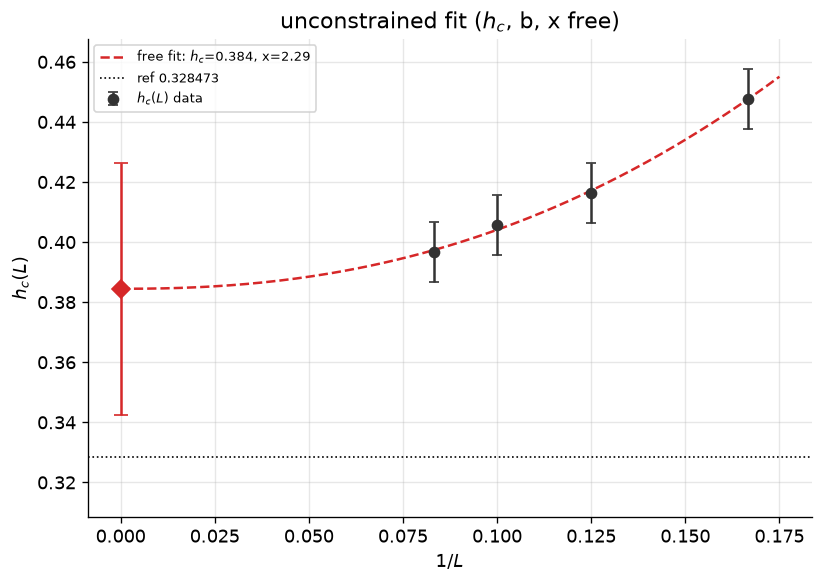

In [149]:
# --- fully unconstrained fit: h_c, b, AND x all free (degenerate for 4 pts, but hey) ---
OB      = list(OBS)                       # observable keys, from the fit cells
SOURCE  = (1, "rich")     # pull h_c(L) from HC: (obs 0=BFFM 1=Rényi, form "tanh"/"rich"); None -> dict below
SOURCE = None

# BFFM $\rho_Z$  [tanh]  L6=0.4428±0.0090  L8=0.4265±0.0041  L10=0.4152±0.0013  L12=0.4016±0.0012
# BFFM $\rho_Z$  [rich]  L6=0.4425±0.0103  L8=0.4272±0.0077  L10=0.4116±0.0029  L12=0.4025±0.0034
# Rényi $S_2$    [tanh]  L6=0.4477±0.0187  L8=0.4163±0.0028  L10=0.4055±0.0014  L12=0.3966±0.0021
# Rényi $S_2$    [rich]  L6=0.4471±0.0192  L8=0.4142±0.0056  L10=0.4080±0.0034  L12=0.4015±0.0055

HC_DATA = HC[(OB[SOURCE[0]], SOURCE[1])] if SOURCE else {6: (0.4477, 0.010), 8: (0.4163, 0.010), 10: (0.4055, 0.010), 12: (0.3966, 0.010)}

# HC_DATA = HC[(OB[SOURCE[0]], SOURCE[1])] if SOURCE else {6: (0.4425, 0.010), 8: (0.4272, 0.010), 10: (0.4116, 0.010), 12: (0.4025, 0.010)}
H_REF   = 0.328473        # reference line

Lk = sorted(HC_DATA); iL = 1/np.array(Lk, float)
y  = np.array([HC_DATA[L][0] for L in Lk]); e = np.array([HC_DATA[L][1] for L in Lk])

f = lambda t, hc, b, x: hc + b*t**x            # all three free
popt, pcov = curve_fit(f, iL, y, p0=[y.min(), 0.5, 1.5], sigma=e, absolute_sigma=True, maxfev=400000)
hc, b, x = popt; hce, be, xe = np.sqrt(np.diag(pcov))
cbx = pcov[1, 2] / np.sqrt(pcov[1, 1] * pcov[2, 2])
print(f"unconstrained:  h_c = {hc:.4f} ± {hce:.4g}   b = {b:.3f} ± {be:.4g}   x = {x:.3f} ± {xe:.4g}")
print(f"                corr(b,x) = {cbx:+.3f}   cond(cov) = {np.linalg.cond(pcov):.1e}   (huge => degenerate)")

fig, ax = plt.subplots(figsize=(7, 5))
tt = np.linspace(0, iL.max()*1.05, 200)
ax.errorbar(iL, y, yerr=e, fmt="o", color="0.2", ms=6, capsize=3, zorder=5, label="$h_c(L)$ data")
ax.plot(tt, f(tt, *popt), "--", color="tab:red", lw=1.5, label=f"free fit: $h_c$={hc:.3f}, x={x:.2f}")
ax.errorbar(0, hc, yerr=hce, fmt="D", color="tab:red", ms=8, capsize=4, zorder=6)
ax.axhline(H_REF, color="k", ls=":", lw=1, label=f"ref {H_REF}")
ax.set(xlabel="$1/L$", ylabel="$h_c(L)$", title="unconstrained fit ($h_c$, b, x free)",
       ylim=(min(H_REF, y.min()) - 0.02, y.max() + 0.02))   # focused; wild extrapolation is clipped (see printout)
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "fss_unconstrained_S2.png", dpi=300, bbox_inches="tight")

---
## Elementary order parameters — magnetization & stabilizers
Same FSS pipeline (tanh / Richards inflection → $1/L$ extrapolation) applied to two *simple* observables instead of BFFM $\rho_Z$ / Rényi $S_2$:

- **$\langle\sigma^z\rangle$** — bulk magnetization (mean over the 12 bulk qubits). Rises $0\to1$ across the transition; the field-aligned order parameter.
- **$\langle A_v\rangle=\langle W_X\rangle$** — the **star / vertex** stabilizer ($\prod\sigma^x$). Disordered by $h_z$, drops $1\to0$. This is the responsive stabilizer for the $h_z$ cut.
- **$\langle B_p\rangle=\langle W_Z\rangle$** — the **plaquette** stabilizer ($\prod\sigma^z$). *Commutes* with the $h_z$ field ⇒ **flat $\equiv1$, no signal** here; shown only as a contamination diagnostic. It becomes the responsive order parameter under an $h_x$ sweep (see note below), which is not in this dataset.

Reuses the machinery from the cells above (`data`, `curve`, `fit`, `tanh_f`, `rich_f`, `fss`, `HZ_FIT`).

> **$h_x$ / $B_p$ duality (future).** Under an $h_x$ (i.e. $\prod\sigma^x$-breaking) sweep the roles swap: $\langle B_p\rangle$ becomes the responsive stabilizer (drops $1\to0$), $\langle A_v\rangle\equiv1$, and the magnetization to track is $\langle\sigma^x\rangle$ (`magnetization_Xmean`). The `OBS_SIMPLE` dict below is built so you only change the accessors — the fit/extrapolation cells are field-agnostic.

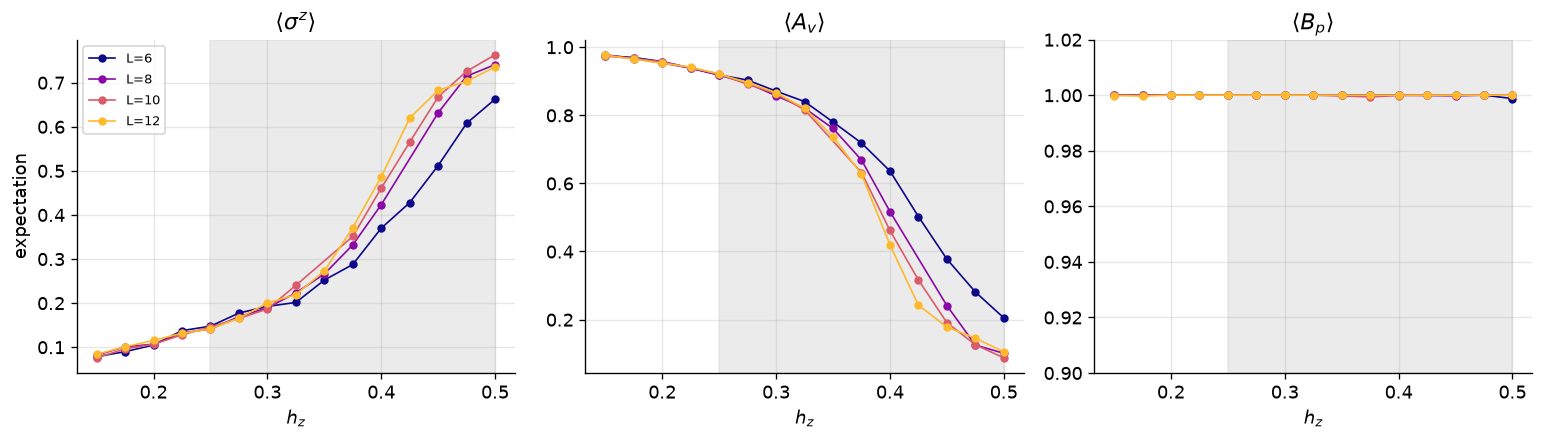

In [151]:
# --- accessors: magnetization + stabilizers (last-step values) ---
mag_z   = lambda d: float(np.mean(d["order_params"]["magnetization_Zmean"][-1]))       # <sigma^z>, rises 0->1
stab_Av = lambda d: d["order_params"]["WilsonBFFM"][-1][0] if d["order_params"]["WilsonBFFM"] else np.nan  # <A_v>=<W_X>, drops 1->0
stab_Bp = lambda d: d["order_params"]["WilsonBFFM"][-1][4] if d["order_params"]["WilsonBFFM"] else np.nan  # <B_p>=<W_Z>, flat under hz

# observables we FIT (responsive to hz); B_p is a flat diagnostic only
OBS_SIMPLE = {r"$\langle\sigma^z\rangle$": mag_z, r"$\langle A_v\rangle$": stab_Av}
DIAG       = {r"$\langle B_p\rangle$": stab_Bp}

# raw curves vs hz, all L overlaid (shaded band = HZ_FIT window used by the fits)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (oname, fn) in zip(axes, {**OBS_SIMPLE, **DIAG}.items()):
    for L in Ls:
        hz, y = curve(L, fn)
        ax.plot(hz, y, "o-", color=cols[L], ms=4, lw=1, label=f"L={L}")
    ax.axvspan(*HZ_FIT, color="0.85", alpha=0.5, zorder=0)
    ax.set(xlabel="$h_z$", title=oname)
axes[0].set_ylabel("expectation"); axes[0].legend(fontsize=8)
axes[2].set_ylim(0.9, 1.02)                       # B_p ~ 1: zoom to show it is flat (no signal)
fig.tight_layout()
# fig.savefig(FIG / "fss_simple_curves.png", dpi=300, bbox_inches="tight")

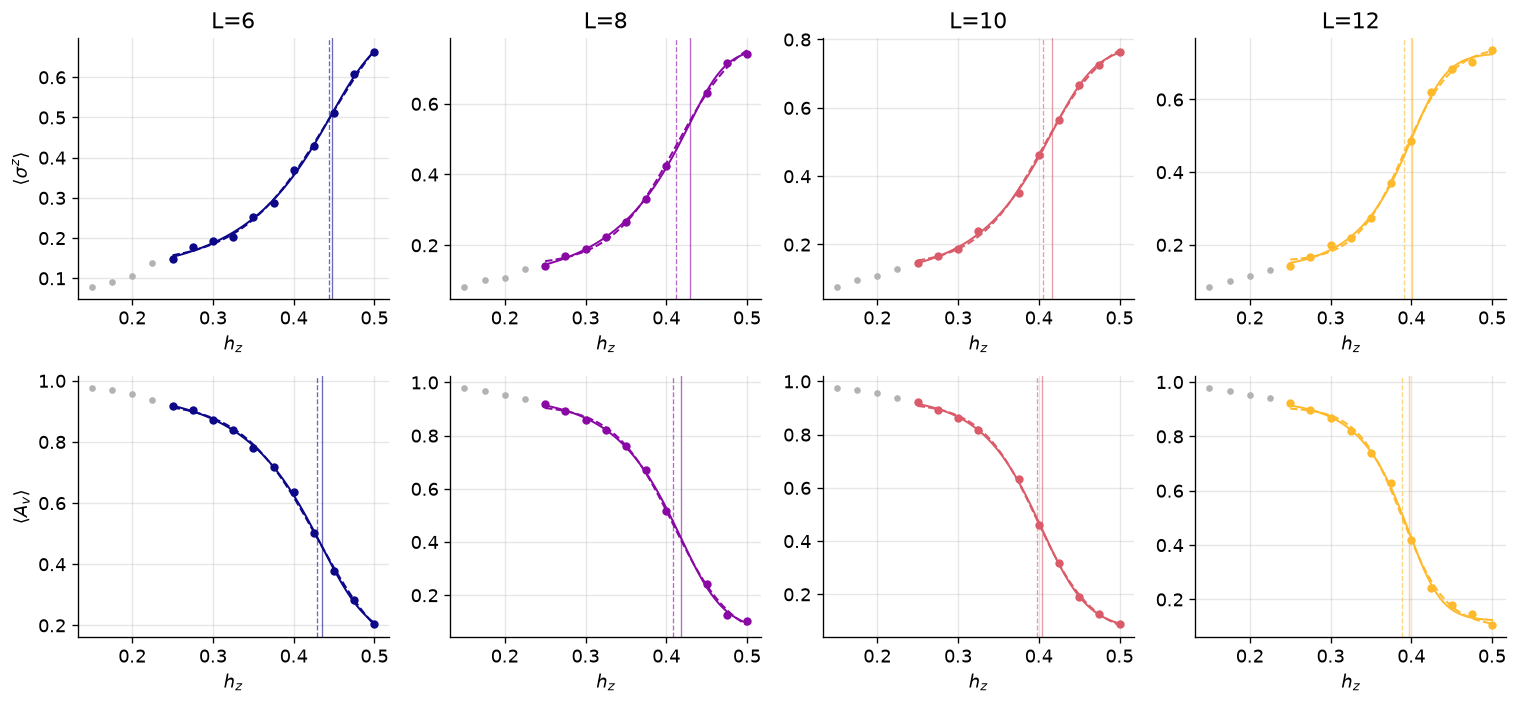

In [152]:
# --- per-(observable, L) tanh + Richards fits; inflection -> h_c(L) into HC_SIMPLE ---
HC_SIMPLE = {}                                   # (obs, form) -> {L: (h_c, err)}
fig, axes = plt.subplots(len(OBS_SIMPLE), len(Ls), figsize=(3.2*len(Ls), 3.0*len(OBS_SIMPLE)), squeeze=False)
for r, (oname, fn) in enumerate(OBS_SIMPLE.items()):
    for c, L in enumerate(Ls):
        ax = axes[r][c]; hz, y = curve(L, fn)
        m = (hz >= HZ_FIT[0]) & (hz <= HZ_FIT[1]); x, yy = hz[m], y[m]
        ax.plot(hz, y, "o", color="0.7", ms=3)
        ax.plot(x, yy, "o", color=cols[L], ms=4)
        xs = np.linspace(x.min(), x.max(), 200)
        for form, ff, ls in [("tanh", tanh_f, "--"), ("rich", rich_f, "-")]:
            try:
                hc, err, popt = fit(x, yy, form)          # fit is sign-agnostic (rising or falling)
                ax.plot(xs, ff(xs, *popt), ls, color=cols[L], lw=1.2)
                ax.axvline(hc, color=cols[L], ls=ls, lw=0.8, alpha=0.6)
                HC_SIMPLE.setdefault((oname, form), {})[L] = (hc, err)
            except Exception as e:
                print(f"{oname} L={L} {form}: fit failed ({e})")
        if r == 0: ax.set_title(f"L={L}")
        if c == 0: ax.set_ylabel(oname)
        ax.set_xlabel("$h_z$")
fig.tight_layout()
# fig.savefig(FIG / "fss_simple_fits.png", dpi=300, bbox_inches="tight")

In [153]:
# --- h_c(L) table for the simple observables ---
print(f"h_c(L) over hz in {HZ_FIT}  (errors from fit covariance, underestimated)\n")
for (oname, form), d in HC_SIMPLE.items():
    row = "  ".join(f"L{L}={d[L][0]:.4f}±{d[L][1]:.4f}" for L in Ls if L in d)
    print(f"{oname:22s} [{form:4s}]  {row}")

h_c(L) over hz in (0.25, 0.5)  (errors from fit covariance, underestimated)

$\langle\sigma^z\rangle$ [tanh]  L6=0.4442±0.0113  L8=0.4125±0.0044  L10=0.4051±0.0030  L12=0.3907±0.0025
$\langle\sigma^z\rangle$ [rich]  L6=0.4469±0.0089  L8=0.4290±0.0043  L10=0.4161±0.0048  L12=0.4012±0.0057
$\langle A_v\rangle$   [tanh]  L6=0.4291±0.0046  L8=0.4084±0.0034  L10=0.3977±0.0016  L12=0.3886±0.0023
$\langle A_v\rangle$   [rich]  L6=0.4354±0.0041  L8=0.4179±0.0057  L10=0.4040±0.0032  L12=0.3977±0.0050


h_c(inf) = h_c + b·L^(-x)   [given x = [1.0, 1.59, 2.0]]   theory 0.328473

$\langle\sigma^z\rangle$ [tanh]  x=1.000: 0.3431±0.0095   x=1.590: 0.3668±0.0058   x=2.000: 0.3751±0.0045
$\langle\sigma^z\rangle$ [rich]  x=1.000: 0.3583±0.0129   x=1.590: 0.3828±0.0082   x=2.000: 0.3915±0.0066
$\langle A_v\rangle$   [tanh]  x=1.000: 0.3492±0.0059   x=1.590: 0.3700±0.0036   x=2.000: 0.3772±0.0028
$\langle A_v\rangle$   [rich]  x=1.000: 0.3584±0.0082   x=1.590: 0.3793±0.0053   x=2.000: 0.3864±0.0044


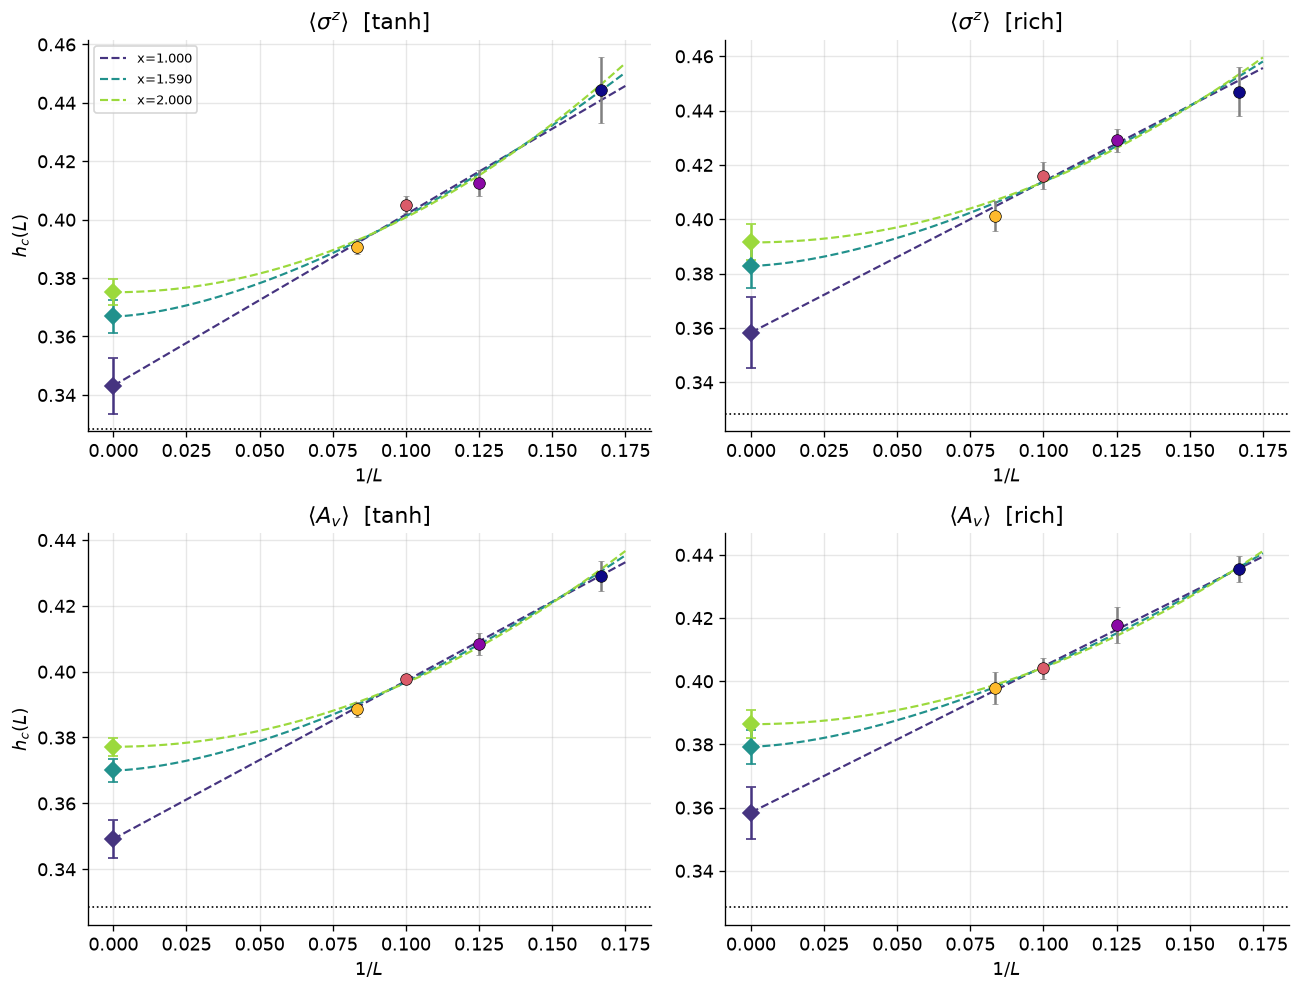

In [156]:
# --- 1/L extrapolation h_c(L) = h_c(inf) + b·L^(-x) at GIVEN fixed exponents ---
# free x is degenerate with 4 sizes (see cell above), so we FIX x and fit (h_c, b).
X_SIMPLE = [1.0, 1/0.629, 2.0]   # given exponents to overlay (1/nu_3DIsing ~ 1.59)
H_THEORY = 0.328473              # 3D-Ising* critical field, h_c = 0.328473(2)

def extrap(Lk, hc, er, x):       # fit h_c(inf), b at a fixed x; returns (h_c_inf, err, b)
    iL = 1.0 / np.array(Lk, float)
    s  = np.array(er) if np.all(np.array(er) > 0) else None
    f  = lambda t, hcinf, b: hcinf + b * t**x
    popt, pcov = curve_fit(f, iL, hc, p0=[min(hc), max(hc) - min(hc)],
                           sigma=s, absolute_sigma=s is not None, maxfev=40000)
    return popt[0], np.sqrt(pcov[0, 0]), popt[1]

xcol = plt.cm.viridis(np.linspace(0.15, 0.85, len(X_SIMPLE)))
fig, axes = plt.subplots(len(OBS_SIMPLE), 2, figsize=(11, 4.2*len(OBS_SIMPLE)), squeeze=False)
print(f"h_c(inf) = h_c + b·L^(-x)   [given x = {[round(x,3) for x in X_SIMPLE]}]   theory {H_THEORY}\n")
for r, oname in enumerate(OBS_SIMPLE):
    for c, form in enumerate(["tanh", "rich"]):
        ax = axes[r][c]; d = HC_SIMPLE[(oname, form)]
        Lk = [L for L in Ls if L in d]
        hc = [d[L][0] for L in Lk]; er = [d[L][1] for L in Lk]
        iL = 1.0 / np.array(Lk, float); tt = np.linspace(0, iL.max()*1.05, 200)
        for L in Lk:                                                    # data: fill = L colour
            ax.errorbar(1/L, d[L][0], yerr=d[L][1], fmt="o", mfc=cols[L], mec="k",
                        mew=0.4, ms=7, ecolor="0.5", capsize=2, zorder=3)
        line = []
        for x, col in zip(X_SIMPLE, xcol):
            hcinf, hcerr, b = extrap(Lk, hc, er, x)
            ax.plot(tt, hcinf + b*tt**x, "--", color=col, lw=1.3, label=f"x={x:.3f}")
            ax.errorbar(0, hcinf, yerr=hcerr, fmt="D", color=col, ms=7, capsize=3, zorder=6)
            line.append(f"x={x:.3f}: {hcinf:.4f}±{hcerr:.4f}")
        ax.axhline(H_THEORY, color="k", ls=":", lw=1)
        ax.set(xlabel="$1/L$", title=f"{oname}  [{form}]")
        if c == 0: ax.set_ylabel("$h_c(L)$")
        print(f"{oname:22s} [{form:4s}]  " + "   ".join(line))
axes[0][0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG / "fss_simple_extrap.png", dpi=300, bbox_inches="tight")